In [1]:
import pandas as pd
from utils.funcs import get_variable_names, rename_columns, processed_diabetes_data, demographic_data2
from functools import reduce
from sklearn.preprocessing import StandardScaler
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
import optuna
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.feature_selection import RFE
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score


c:\Users\bipan\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def read_file(filename=''):

    dataset_path='raw_datasets'
    df=pd.read_sas(f'{dataset_path}/{filename}.XPT', format='xport')
    mapping=get_variable_names()
    df=rename_columns(df, mapping)  
    
    return df

In [5]:
df_diabetes=processed_diabetes_data()  
df_demographic=demographic_data2()
df_audio=read_file('audiometry')
df_blood_pressure=read_file('blood_pressure_cholesterol')
df_general_health=read_file('hospital_utilization_access_to_care')
df_weight=read_file('weight_history')
df_occupation=read_file('occupation')

In [6]:
dataframes = [df_diabetes,df_demographic, df_audio, df_blood_pressure, df_general_health, df_weight, df_occupation]
df = reduce(lambda left, right: pd.merge(left, right, on='sequence_no', how='inner'), dataframes)
columns_to_select = ['sequence_no', 'EverTold_Diabetes', 'gender', 'age','sample_weight','sample_weight2','HearingStatus_NoAid','EverTold_Hypertension','EverTold_HighCholesterol','GeneralHealth_Status','CurrentHeight','CurrentWeight','WorkExperience_LastWeek','WeightOneYearAgo']
df=df[columns_to_select]
df['bmi']=(df['CurrentWeight']/(df['CurrentHeight']**2))*703
df['weight_diff']=df['CurrentWeight']-df['WeightOneYearAgo']
df = df.dropna()


In [5]:
df = df.drop(['CurrentHeight', 'CurrentWeight','WeightOneYearAgo'], axis=1)

### Corelation of selected features

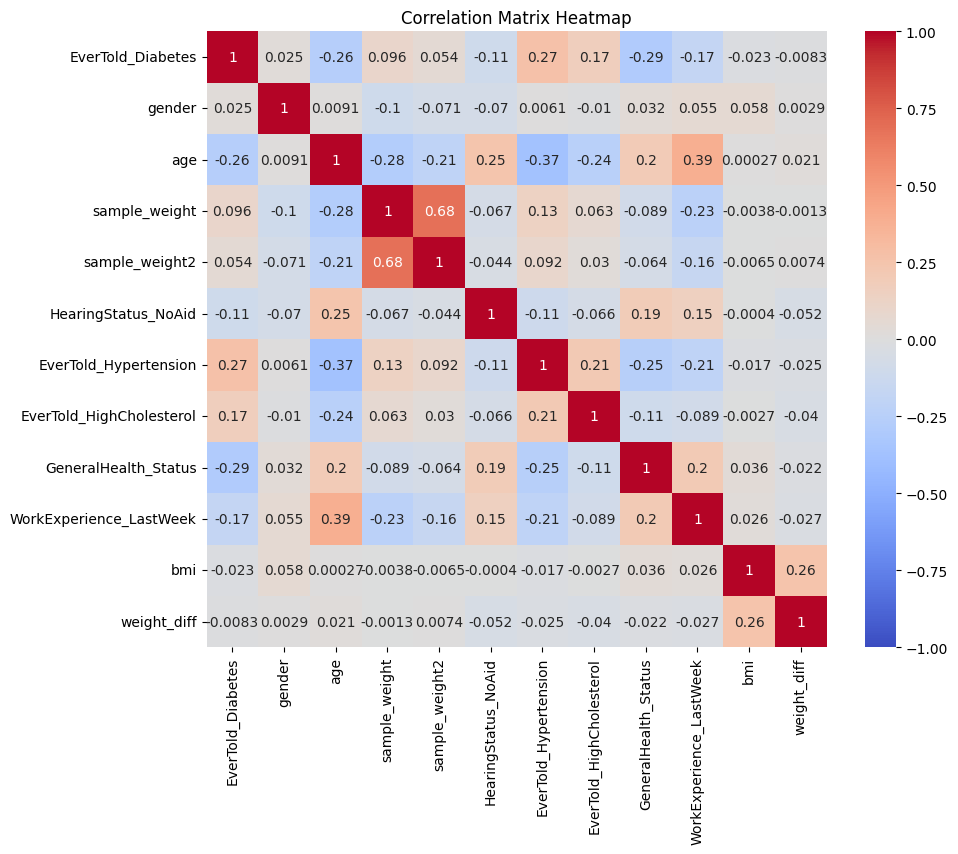

In [8]:
df1 = df.drop('sequence_no', axis=1)  
corr_matrix = df1.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [17]:
df.columns

Index(['sequence_no', 'EverTold_Diabetes', 'gender', 'age', 'sample_weight',
       'sample_weight2', 'HearingStatus_NoAid', 'EverTold_Hypertension',
       'EverTold_HighCholesterol', 'GeneralHealth_Status',
       'WorkExperience_LastWeek', 'bmi', 'weight_diff'],
      dtype='object')

In [6]:
categorical_columns = ['gender', 'HearingStatus_NoAid', 'EverTold_Hypertension', 'EverTold_HighCholesterol', 'GeneralHealth_Status','WorkExperience_LastWeek']
df[categorical_columns]=df[categorical_columns].astype(int)

In [7]:
y = df["EverTold_Diabetes"] 
X = df.drop(['EverTold_Diabetes','sequence_no'], axis=1)  
y=y.map({1.0: 1, 2.0: 0})

### Different Approaches for checking feature Importance

Use tree-based model-Random Forest to compute feature importances and drop low-importance features.



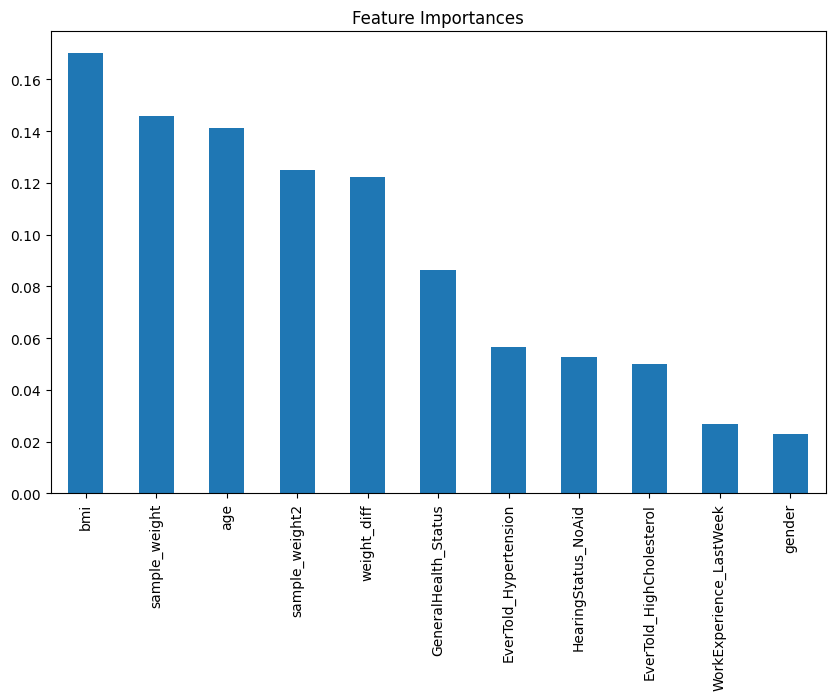

In [19]:
model = RandomForestClassifier()
model.fit(X, y)

feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances.sort_values(ascending=False).plot(kind='bar', figsize=(10, 6))
plt.title("Feature Importances")
plt.show()

Use statistical tests

In [20]:
selector = SelectKBest(score_func=f_classif, k=8) 
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]
print("Selected features:", selected_features)


Selected features: Index(['age', 'sample_weight', 'sample_weight2', 'HearingStatus_NoAid',
       'EverTold_Hypertension', 'EverTold_HighCholesterol',
       'GeneralHealth_Status', 'WorkExperience_LastWeek'],
      dtype='object')


### Light GBM with optuna for hyperparameters tuning

SMOTE + Tomek 

In [ ]:
def objective(trial, sampling=None):
    params = {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.3),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 100),
        "feature_fraction": trial.suggest_uniform("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_uniform("bagging_fraction", 0.6, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
        "lambda_l1": trial.suggest_loguniform("lambda_l1", 1e-8, 10.0),
        "lambda_l2": trial.suggest_loguniform("lambda_l2", 1e-8, 10.0),
    }
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []
    for train_idx, valid_idx in skf.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
        scaler = StandardScaler()
        smote_rus = SMOTETomek(random_state=42)
        X_train_scaled = scaler.fit_transform(X_train)
        X_resampled, y_resampled = smote_rus.fit_resample(X_train_scaled, y_train)
        X_valid_scaled = scaler.transform(X_valid)

        train_data = lgb.Dataset(X_resampled, label=y_resampled)
        valid_data = lgb.Dataset(X_valid_scaled, label=y_valid, reference=train_data)

        scale_pos_weight = len(y_resampled[y_resampled == 0]) / len(y_resampled[y_resampled == 1])
        params["scale_pos_weight"] = scale_pos_weight

        model = lgb.train(
            params,
            train_data,
            valid_sets=[valid_data],
            valid_names=["valid"],
            num_boost_round=500,
            callbacks=[
                lgb.early_stopping(stopping_rounds=30),
                lgb.log_evaluation(period=50),
            ],
        )

        y_pred = model.predict(X_valid_scaled)
        auc = roc_auc_score(y_valid, y_pred)
        auc_scores.append(auc)

    return sum(auc_scores) / len(auc_scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)  

best_params = study.best_params
print("Best Parameters:", best_params)

In [ ]:

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracy_scores = []
auroc_scores = []

for train_idx, valid_idx in skf.split(X, y):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    scaler = StandardScaler()
    smote = SMOTETomek(random_state=42)
    X_train_scaled = scaler.fit_transform(X_train)
    X_resampled, y_resampled = smote.fit_resample(X_train_scaled, y_train)

    X_valid_scaled = scaler.transform(X_valid)

    train_data = lgb.Dataset(X_resampled, label=y_resampled)
    valid_data = lgb.Dataset(X_valid_scaled, label=y_valid, reference=train_data)

    scale_pos_weight = len(y_resampled[y_resampled == 0]) / len(y_resampled[y_resampled == 1])
    best_params["scale_pos_weight"] = scale_pos_weight

    model = lgb.train(
        best_params,
        train_data,
        valid_sets=[valid_data],
        valid_names=["valid"],
        num_boost_round=500,
        callbacks=[
            lgb.early_stopping(stopping_rounds=30),
            lgb.log_evaluation(period=50),
        ],
    )

    y_pred_proba = model.predict(X_valid_scaled)  
    y_pred = (y_pred_proba > 0.5).astype(int)  

    auroc = roc_auc_score(y_valid, y_pred_proba)
    accuracy = accuracy_score(y_valid, y_pred)

    auroc_scores.append(auroc)
    accuracy_scores.append(accuracy)

In [ ]:
average_auroc = sum(auroc_scores) / len(auroc_scores)
average_accuracy = sum(accuracy_scores) / len(accuracy_scores)

print(f"Average AUROC from K-Fold Cross Validation: {average_auroc:.4f}")
print(f"Average Accuracy from K-Fold Cross Validation: {average_accuracy:.4f}")

Average AUROC from K-Fold Cross Validation: 0.8360
Average Accuracy from K-Fold Cross Validation: 0.8619


No sampling 

In [ ]:
def objective(trial):
    params = {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "learning_rate": trial.suggest_loguniform("learning_rate", 0.005, 0.3),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 5, 200),
        "feature_fraction": trial.suggest_uniform("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_uniform("bagging_fraction", 0.6, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
        "lambda_l1": trial.suggest_loguniform("lambda_l1", 1e-8, 10.0),
        "lambda_l2": trial.suggest_loguniform("lambda_l2", 1e-8, 10.0),
        "min_gain_to_split": trial.suggest_loguniform("min_gain_to_split", 1e-8, 1.0),
        "scale_pos_weight": trial.suggest_uniform("scale_pos_weight", 0.1, 10.0),
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []
    
    for train_idx, valid_idx in skf.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        for col in categorical_columns:
            X_train[col] = X_train[col].astype("category")
            X_valid[col] = X_valid[col].astype("category")

        numerical_columns = [col for col in X_train.columns if col not in categorical_columns]
        scaler = StandardScaler()
        X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
        X_valid[numerical_columns] = scaler.transform(X_valid[numerical_columns])

        train_data = lgb.Dataset(X_train, label=y_train,categorical_feature=categorical_columns)
        valid_data = lgb.Dataset(X_valid, label=y_valid, reference=train_data)


        model = lgb.train(
            params,
            train_data,
            valid_sets=[valid_data],
            valid_names=["valid"],
            num_boost_round=1000,
            callbacks=[
                lgb.early_stopping(stopping_rounds=30),
                lgb.log_evaluation(period=50),
            ],
        )

        y_pred = model.predict(X_valid)
        auc = roc_auc_score(y_valid, y_pred)
        auc_scores.append(auc)

    return sum(auc_scores) / len(auc_scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100,timeout=3600) 

best_params = study.best_params
print("Best Parameters:", best_params)




In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracy_scores = []
auroc_scores = []

for train_idx, valid_idx in skf.split(X, y):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    X_valid_scaled = scaler.transform(X_valid)

    train_data = lgb.Dataset(X_train_scaled, label=y_train)
    valid_data = lgb.Dataset(X_valid_scaled, label=y_valid, reference=train_data)

    scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
    best_params["scale_pos_weight"] = scale_pos_weight

    model = lgb.train(
        best_params,
        train_data,
        valid_sets=[valid_data],
        valid_names=["valid"],
        num_boost_round=500,
        callbacks=[
            lgb.early_stopping(stopping_rounds=30),
            lgb.log_evaluation(period=50),
        ],
    )

    y_pred_proba = model.predict(X_valid_scaled) 
    y_pred = (y_pred_proba > 0.5).astype(int)  

    auroc = roc_auc_score(y_valid, y_pred_proba)
    accuracy = accuracy_score(y_valid, y_pred)

    auroc_scores.append(auroc)
    accuracy_scores.append(accuracy)

In [19]:
average_auroc = sum(auroc_scores) / len(auroc_scores)
average_accuracy = sum(accuracy_scores) / len(accuracy_scores)

print(f"Average AUROC from K-Fold Cross Validation: {average_auroc:.4f}")
print(f"Average Accuracy from K-Fold Cross Validation: {average_accuracy:.4f}")

Average AUROC from K-Fold Cross Validation: 0.8520
Average Accuracy from K-Fold Cross Validation: 0.8769


SMOTE

In [ ]:
def objective(trial):
    params = {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.3),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 100),
        "feature_fraction": trial.suggest_uniform("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_uniform("bagging_fraction", 0.6, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
        "lambda_l1": trial.suggest_loguniform("lambda_l1", 1e-8, 10.0),
        "lambda_l2": trial.suggest_loguniform("lambda_l2", 1e-8, 10.0),
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []

    for train_idx, valid_idx in skf.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        scaler = StandardScaler()
        smote = SMOTE(random_state=42)
        X_train_scaled = scaler.fit_transform(X_train)
        X_resampled, y_resampled = smote.fit_resample(X_train_scaled, y_train)

        X_valid_scaled = scaler.transform(X_valid)

        train_data = lgb.Dataset(X_resampled, label=y_resampled)
        valid_data = lgb.Dataset(X_valid_scaled, label=y_valid, reference=train_data)

        scale_pos_weight = len(y_resampled[y_resampled == 0]) / len(y_resampled[y_resampled == 1])
        params["scale_pos_weight"] = scale_pos_weight

        model = lgb.train(
            params,
            train_data,
            valid_sets=[valid_data],
            valid_names=["valid"],
            num_boost_round=500,
            callbacks=[
                lgb.early_stopping(stopping_rounds=30),
                lgb.log_evaluation(period=50),
            ],
        )

        y_pred = model.predict(X_valid_scaled)
        auc = roc_auc_score(y_valid, y_pred)
        auc_scores.append(auc)

    return sum(auc_scores) / len(auc_scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)  

best_params = study.best_params
print("Best Parameters:", best_params)

In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracy_scores = []
auroc_scores = []

for train_idx, valid_idx in skf.split(X, y):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    scaler = StandardScaler()
    smote = SMOTE(random_state=42)
    X_train_scaled = scaler.fit_transform(X_train)
    X_resampled, y_resampled = smote.fit_resample(X_train_scaled, y_train)

    X_valid_scaled = scaler.transform(X_valid)

    train_data = lgb.Dataset(X_resampled, label=y_resampled)
    valid_data = lgb.Dataset(X_valid_scaled, label=y_valid, reference=train_data)

    scale_pos_weight = len(y_resampled[y_resampled == 0]) / len(y_resampled[y_resampled == 1])
    best_params["scale_pos_weight"] = scale_pos_weight

    model = lgb.train(
        best_params,
        train_data,
        valid_sets=[valid_data],
        valid_names=["valid"],
        num_boost_round=500,
        callbacks=[
            lgb.early_stopping(stopping_rounds=30),
            lgb.log_evaluation(period=50),
        ],
    )

    y_pred_proba = model.predict(X_valid_scaled)  
    y_pred = (y_pred_proba > 0.5).astype(int)  

    auroc = roc_auc_score(y_valid, y_pred_proba)
    accuracy = accuracy_score(y_valid, y_pred)

    auroc_scores.append(auroc)
    accuracy_scores.append(accuracy)

In [ ]:
average_auroc = sum(auroc_scores) / len(auroc_scores)
average_accuracy = sum(accuracy_scores) / len(accuracy_scores)

print(f"Average AUROC from K-Fold Cross Validation: {average_auroc:.4f}")
print(f"Average Accuracy from K-Fold Cross Validation: {average_accuracy:.4f}")

Average AUROC from K-Fold Cross Validation: 0.8349
Average Accuracy from K-Fold Cross Validation: 0.8608


Only Tomek

In [ ]:
def objective(trial):
    params = {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.3),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 100),
        "feature_fraction": trial.suggest_uniform("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_uniform("bagging_fraction", 0.6, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
        "lambda_l1": trial.suggest_loguniform("lambda_l1", 1e-8, 10.0),
        "lambda_l2": trial.suggest_loguniform("lambda_l2", 1e-8, 10.0),
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []

    for train_idx, valid_idx in skf.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        scaler = StandardScaler()
        rus = RandomUnderSampler(random_state=42)
        X_train_scaled = scaler.fit_transform(X_train)
        X_resampled, y_resampled = rus.fit_resample(X_train_scaled, y_train)

        X_valid_scaled = scaler.transform(X_valid)

        train_data = lgb.Dataset(X_resampled, label=y_resampled)
        valid_data = lgb.Dataset(X_valid_scaled, label=y_valid, reference=train_data)

        scale_pos_weight = len(y_resampled[y_resampled == 0]) / len(y_resampled[y_resampled == 1])
        params["scale_pos_weight"] = scale_pos_weight

        model = lgb.train(
            params,
            train_data,
            valid_sets=[valid_data],
            valid_names=["valid"],
            num_boost_round=500,
            callbacks=[
                lgb.early_stopping(stopping_rounds=30),
                lgb.log_evaluation(period=50),
            ],
        )

        y_pred = model.predict(X_valid_scaled)
        auc = roc_auc_score(y_valid, y_pred)
        auc_scores.append(auc)

    return sum(auc_scores) / len(auc_scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

best_params = study.best_params
print("Best Parameters:", best_params)

In [ ]:
scaler = StandardScaler()
rus = RandomUnderSampler(random_state=42)
X_scaled = scaler.fit_transform(X)
X_resampled, y_resampled = rus.fit_resample(X_scaled, y)

train_data = lgb.Dataset(X_resampled, label=y_resampled)
final_model = lgb.train(
    best_params,
    train_data,
    num_boost_round=500,
    callbacks=[lgb.log_evaluation(period=50)],
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracy_scores = []
auroc_scores = []

for train_idx, valid_idx in skf.split(X, y):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    X_train_scaled = scaler.fit_transform(X_train)
    X_resampled, y_resampled = rus.fit_resample(X_train_scaled, y_train)

    X_valid_scaled = scaler.transform(X_valid)

    train_data = lgb.Dataset(X_resampled, label=y_resampled)
    valid_data = lgb.Dataset(X_valid_scaled, label=y_valid, reference=train_data)

    scale_pos_weight = len(y_resampled[y_resampled == 0]) / len(y_resampled[y_resampled == 1])
    best_params["scale_pos_weight"] = scale_pos_weight

    model = lgb.train(
        best_params,
        train_data,
        valid_sets=[valid_data],
        valid_names=["valid"],
        num_boost_round=500,
        callbacks=[
            lgb.early_stopping(stopping_rounds=30),
            lgb.log_evaluation(period=50),
        ],
    )

    y_pred_proba = model.predict(X_valid_scaled) 
    y_pred = (y_pred_proba > 0.5).astype(int) 

    auroc = roc_auc_score(y_valid, y_pred_proba)
    accuracy = accuracy_score(y_valid, y_pred)

    auroc_scores.append(auroc)
    accuracy_scores.append(accuracy)


In [ ]:
average_auroc = sum(auroc_scores) / len(auroc_scores)
average_accuracy = sum(accuracy_scores) / len(accuracy_scores)

print(f"Average AUROC from K-Fold Cross Validation with RUS: {average_auroc:.4f}")
print(f"Average Accuracy from K-Fold Cross Validation with RUS: {average_accuracy:.4f}")

Average AUROC from K-Fold Cross Validation with RUS: 0.8482
Average Accuracy from K-Fold Cross Validation with RUS: 0.7380


### SVM

In [ ]:
def evaluate_with_kfold(X, y, sampler=None, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    svm = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
    
    if sampler:
        pipeline = Pipeline(steps=[('scaler', StandardScaler()),('sampler', sampler), ('svm', svm)])
    else:
        pipeline = Pipeline(steps=[('scaler', StandardScaler()),('svm', svm)])
    
    auc_scores = []
    accuracy_scores = []

    for train_idx, valid_idx in skf.split(X, y):
        X_train, X_valid = X[train_idx], X[valid_idx]
        y_train, y_valid = y[train_idx], y[valid_idx]

        pipeline.fit(X_train, y_train)

        y_pred_proba = pipeline.predict_proba(X_valid)
        y_pred = (y_pred_proba[:, 1] >= 0.5).astype(int)

        auc_roc = roc_auc_score(y_valid, y_pred_proba[:, 1])
        accuracy = accuracy_score(y_valid, y_pred)

        auc_scores.append(auc_roc)
        accuracy_scores.append(accuracy)

    avg_auc = np.mean(auc_scores)
    avg_accuracy = np.mean(accuracy_scores)
    
    return avg_auc, avg_accuracy

X_np = np.array(X)  
y_np = np.array(y)

auc_original, acc_original = evaluate_with_kfold(X_np, y_np)

smote = SMOTE(random_state=42)
auc_smote, acc_smote = evaluate_with_kfold(X_np, y_np, sampler=smote)

rus = RandomUnderSampler(random_state=42)
auc_rus, acc_rus = evaluate_with_kfold(X_np, y_np, sampler=rus)

smote_rus = SMOTETomek(random_state=42)
auc_smote_rus, acc_smote_rus = evaluate_with_kfold(X_np, y_np, sampler=smote_rus)

print("Summary of Results")
print(f"Original Data AUC-ROC: {auc_original:.4f}, Accuracy: {acc_original:.4f}")
print(f"SMOTE AUC-ROC: {auc_smote:.4f}, Accuracy: {acc_smote:.4f}")
print(f"RUS AUC-ROC: {auc_rus:.4f}, Accuracy: {acc_rus:.4f}")
print(f"SMOTE + RUS AUC-ROC: {auc_smote_rus:.4f}, Accuracy: {acc_smote_rus:.4f}")



### Summary of Results ###
Original Data AUC-ROC: 0.8281, Accuracy: 0.8683
SMOTE AUC-ROC: 0.8221, Accuracy: 0.7446
RUS AUC-ROC: 0.8273, Accuracy: 0.7110
SMOTE + RUS AUC-ROC: 0.8223, Accuracy: 0.7437


In [ ]:
from sklearn.svm import SVC

svm = SVC(kernel='linear', random_state=42)
rfe = RFE(estimator=svm, n_features_to_select=8) 
X_reduced = rfe.fit_transform(X, y)
print("Selected Features:", X.columns[rfe.support_])
